# TrendMomentumRank

**Cel programu:**

Program wybiera top *n* (Dla naszego przykładu n=10) spółek z listy s&p 500 (503 spółek), a następnie porównuje wynik portfela równych wag tych *n* spółek z całym indeksem s&p 500 w przeciągu *6* lat .

Przykładowe parametry są dobrane tak, aby ograniczyć zużycie i dla naszych założeń 252 to liczba sesji giełdowych w roku

**Kryteria wyboru spółek:**

Dla każdej spółki program oblicza:

- 12- miesięczna momentum
- średni zwrot i zmienność (Sharpe Score)
- Trend $R^2$ logarytmowanych cen

A następnie wskaźniki są normowane *(Z-score)* i sumowane, tworząc *Final Score*, na podstawie którego wybierane są spółki do portfela.

**Portfel**

Jest konstruowany jako równowagowy, czyli każda ze spółek ma wagę *1/n*

**Raport:**

Program generuje plik Excela z następującymi danymi:

1. Ranking
2. Symbol
3. Wskaźnik momentum
4. Sharpe Score
5. Trend
6. Kapitalizacja rynkowa
7. P/E Trailing

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import datetime as dt
import requests
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

## Analiza kodu

### Pobranie i porządkowanie danych:
Do pobrania danych i uporządkowania danych służa dwie funkcje: **ticker_list** oraz **historic_data**, gdzie:

**ticker_list** --> Pobiera listę spółek S&P 500:

- Używa *User-Agent*, aby się "podszyć" pod przeglądarke w celu uniknięcia błędu 403
  - Używa biblioteki `request`, który wysyła HTTP GET zapytanie do URL
  - `response.text` konwertuje surowy HTTP w string
- Konwertuje *'.'* w *'-'*, aby pasowało do fomratu Yahoo finance

**historic_data** --> Pobiera dane historczyne i je porządkuje:

- Pobiera aktualny czas i liczy czas przesunięty o t=6, czyli zwraca dane z 6 lat
- Pobiera dane z Yahoo finance jako *"raw"*
- Następnie dokonuje przekształceń:
  -  przekształca kolumny w wiersze (`stack()`)
  -  zmiennia indexy w zwykłe kolumny (`reset_index`)
  
- Zmienia nazwy kolumn i konwertuje kolumny `date` na czasowe, aby umożliwić operację

- Tworzy macierz cen, gdzie: (`pivot()`)
  - wiersze -> daty
  - kolumny -> symbole akcji
  - wartości -> ceny skorygowane (adj_close)

- Usuwa kolumny z wartościami mniejszymi niż 1500 wartości (ok 6*252 dni rynkowych)
- Oblicza dzienne stopy zwrotu




### Część Matematyczna:

Wykonuje obliczenia tworząc finalny scoring akcji. W celu osiągniecia tego użyto następującyh funkcji: **trend_r2**, **z_score**, **select_top**

@staticmethod --> Pozwala ominąć odwoływania się atrybótwów instancji (`self`)

**trend_r2** --> oblicza współczynnik determinacji $R^2$ dla logarytmu cen w serii. Jest to miara statystyczna pokazująca, jaka część zmienności cen może być wyjaśniona liniowym trendem w czasie. Wartości $R^2$ bliższe 1 oznaczają silniejszy trend, natomiast wartości bliskie 0 sugerują większą losowość zmian cen. Dla serii krótszych niż 252 dni funkcja zwraca NaN, aby uniknąć niepewnych przybliżeń na zbyt małej próbce:

- `x = np.arange(len(y))` tworzy zmienną niezależną x będącą numerem dnia. Gdzie niezależna to czas, a zależna to logarytm ceny
  
- `X = sm.add_constant(x)` dodaje stała w modelu regresji, aby dostać równanie: $ln(cena) = a + b * t$

- `sm.OLS(y, X).fit()` tworzy model *y~x* regresji liniowej, dopasowywując go metodą najmniejszych kwadratów

- `model.rsquared` zwraca spółczynik dtereminacji określony wzorem:  $R^2 = 1-\frac{SSE}{SST}$, gdzie SSE = suma kwadratów błędów (różnica między obserwowanymi a przewidywanymi wartościami), SST = całkowita suma kwadratów odchylenia od średniej


**z_score** --> oblicza standaryzację (średnia wynosiła 0, a odchylenie standardowe 1), dla każdego elementu w serii, aby móc porównać różne wartości w tej samej skali:

Gdzie wzór to: $z_i = \frac{x_i - \overline{x}}{\sigma}$


**select_top** --> oblicza dla każdej spółki 12-miesięczne momentum, uproszczony wskaźnik Sharpe’a i miarę trendu R², standaryzuje te wskaźniki i sumuje je w jednolity wynik rankingowy, a następnie wybiera *top_n* najwyżej ocenionych spółek:

- `momentum_12m` liczy momentum określone wzorem: $momentum = \frac{P_{ostatni dzień}}{P_{252 dni temu}} - 1$
  
- `sharpe_score` określa relację średniego zwrotu do ponoszonego ryzyka, mierzonego odchyleniem standardowym zwrotów. Wyższa wartość oznacza lepszą relację do ryzyka: $S = \frac{\mu}{\sigma}$
  
- `score` sumuje znormalizowane wyniki tworząc scoring końcowy

### Budowa portfela o równych wagach
Funkcja `build_portfolio` wyciąga macierz zwrotów dla *top n* spółek, a następnie daję wagę równą $\frac{1}{n}$ dla każdej spółki oraz oblicza dzienny zwrot z portfela jako sumę ważoną zwrotów wszystkich spółek

### Wykres

Funckja `plot_performance` tworzy wykres porównujący zwrot naszego portfela i całego indeksu s&p 500:
- `spy` pobiera historyczne dane indeksu w tym samym okresie, co dane portfela, dzięki czemu liczba obserwacji jest dopasowana do portfela.
  
- `port_equity` i `spy_equity` kumulują dzienne zwroty, tworząc linie trendu z wartością początkową równą 1, umożliwiające bezpośrednie porównanie dynamiki zwrotów portfela

### kod

In [2]:
class MomentumPortfolio:
    def __init__(self, years: int = 6, top_n: int = 10):
        self.years = years
        self.top_n = top_n
        self.symbol_list = []
        self.prices = pd.DataFrame()
        self.returns = pd.DataFrame()
        self.selected = []
        self.portfolio_returns = pd.Series()

   # Pobranie listy spółek S&P 500
    def ticker_list(self):
        url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
        headers = {'User-Agent': 'Mozilla/5.0'}
        response = requests.get(url, headers=headers)
        tables = pd.read_html(response.text)
        sp500 = tables[0]
        sp500['Symbol'] = sp500['Symbol'].str.replace('.', '-', regex=False)
        self.symbol_list = sp500['Symbol'].unique().tolist()

    
    # Pobranie danych historycznych
    def historic_data(self):
        end_date = dt.datetime.now()
        start_date = end_date - pd.DateOffset(years=self.years)
        raw = yf.download(
            tickers=self.symbol_list,
            start=start_date,
            end=end_date,
            auto_adjust=False,
            timeout=60
        )
        stacked = raw[['Adj Close']].stack().reset_index() 
        stacked.columns = ['date', 'ticker', 'adj_close'] # zmiana nazw kolumn
        stacked['date'] = pd.to_datetime(stacked['date']) # konwersja na datetime
        self.prices = stacked.pivot(index='date', columns='ticker', values='adj_close')
        self.prices = self.prices.dropna(axis=1, thresh=1500)
        self.returns = self.prices.pct_change().dropna() # obliczenie dziennych zwrotów i usunięcie NaN

    # trend R²
    @staticmethod
    def trend_r2(series: pd.Series) -> float:
        y = np.log(series.dropna()) # logarytmowanie cen i usunięcie NaN
        if len(y) < 252:
            return np.nan
        x = np.arange(len(y))
        X = sm.add_constant(x)
        model = sm.OLS(y, X).fit() # dopasowanie modelu OLS (najmniejszych kwadratów)
        return model.rsquared # zwrócenie R²


    # Z-score
    @staticmethod
    def z_score(s: pd.Series) -> pd.Series:
        return (s - s.mean()) / s.std(ddof=0) #ddof=0 to stopień swobody dla populacji

   
    # Scoring i wybór top spółek
    def select_top(self):
        momentum_12m = self.prices.iloc[-1] / self.prices.iloc[-252] - 1
        mean_ret = self.returns.mean() # średni dzienny zwrot
        vol = self.returns.std() # odchylenie standardowe dziennych zwrotów
        sharpe_score = mean_ret / vol.replace(0, np.nan)
        trend_score = self.prices.apply(self.trend_r2)

        self.momentum_12m = momentum_12m
        self.sharpe_score = sharpe_score
        self.trend_score = trend_score
        self.score = self.z_score(momentum_12m) + self.z_score(sharpe_score) + self.z_score(trend_score)

        self.selected = self.score.sort_values(ascending=False).head(self.top_n).index.tolist()
        print("Wybrane spółki:", self.selected)

    # Eksport wyników do Excela
    def export_results(self):
        final_data = pd.DataFrame({
            'Symbol': self.selected,
            'Momentum 12m': self.momentum_12m.loc[self.selected] * 100,
            'Sharpe Score': self.sharpe_score.loc[self.selected],
            'Trend': self.trend_score.loc[self.selected],
            'Final Score': self.score.loc[self.selected],
        }).set_index('Symbol').sort_values(by='Final Score', ascending=False)

        final_data = final_data.reset_index()
        final_data.insert(0, 'Lp.', np.arange(1, len(final_data) + 1))

        market_info = []
        for symbol in final_data['Symbol']:
            try:
                info = yf.Ticker(symbol).info
                market_info.append({
                    'Kapitalizacja Rynkowa': info.get('marketCap'),
                    'P/E Trailing': info.get('trailingPE')
                })
            except:
                market_info.append({
                    'Kapitalizacja Rynkowa': np.nan,
                    'P/E Trailing': np.nan
                })

        df_market = pd.DataFrame(market_info)
        final_export_data = pd.concat([final_data, df_market], axis=1)

        final_export_data.to_excel(
            "Raport_Strategia_Momentum.xlsx",
            index=False,
            sheet_name='Ranking i Wskaźniki'
        )

    # Portfel równych wag
    def build_portfolio(self):
        ret_sel = self.returns[self.selected] # zwroty wybranych spółek
        weights = np.ones(len(self.selected)) / len(self.selected) # np.ones tworzy tablicę jedynek
        self.portfolio_returns = (ret_sel * weights).sum(axis=1)

    # Porównanie z indeksem S&P 500
    def plot_performance(self, benchmark: str = 'SPY'):
        spy = yf.download(benchmark, start=self.returns.index[0], end=self.returns.index[-1], auto_adjust=True)
        spy_ret = spy['Close'].pct_change().dropna() # procentowe zmiany cen zamknięcia
        port_equity = (1 + self.portfolio_returns).cumprod() # skumulowana wartość portfela
        spy_equity = (1 + spy_ret).cumprod()
        plt.figure(figsize=(11,6)) # 11 na 6 cali
        plt.plot(port_equity, label=f'Portfel {self.top_n} spółek (równych wag)')
        plt.plot(spy_equity, label=f'S&P 500 ({benchmark})')
        plt.title("Porównanie wyników portfela z benchmarkiem")
        plt.xlabel("Data")
        plt.ylabel("Wartość portfela (start = 1)")
        plt.legend()
        plt.grid(True) # Dodanie siatki do wykresu
        plt.tight_layout() # Automatyczne dopasowanie elementów wykresu
        plt.show()


In [3]:

portfolio = MomentumPortfolio(years=6, top_n=10)
portfolio.ticker_list()
portfolio.historic_data()


[*********************100%***********************]  503 of 503 completed


In [4]:
# wybór top spółek i budowa portfela
portfolio.select_top()
portfolio.build_portfolio()

Wybrane spółki: ['STX', 'AVGO', 'WDC', 'APH', 'MU', 'KLAC', 'LRCX', 'PWR', 'NVDA', 'HWM']


[*********************100%***********************]  1 of 1 completed


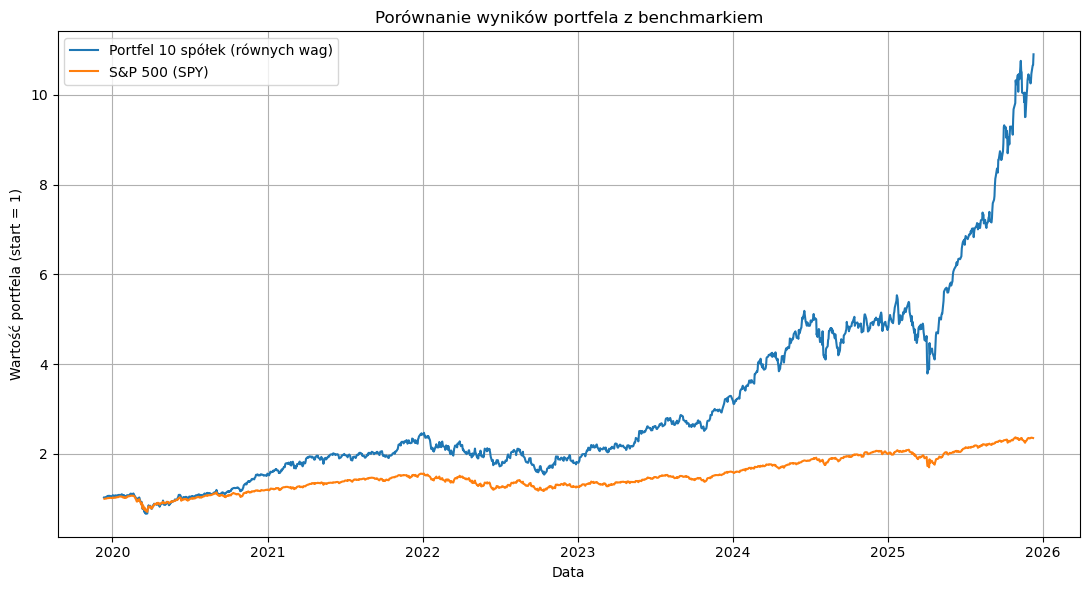

In [5]:
# Wykres i import wyników
portfolio.export_results()
portfolio.plot_performance()